# SecureMail AI - ML Training

This notebook trains the ML model for **SecureMail AI: Intelligent Phishing Detection Using Email Intent and Behavioral Analysis**.

Run the cells from top to bottom. Upload `phishing_email.csv` when asked. The dataset must contain:

- `text_combined`
- `label`

Final outputs:

- `phishing_model.pkl`
- `vectorizer.pkl`
- `model_results.csv`

In [1]:
# Cell 1: Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn joblib nltk -q

In [2]:
# Cell 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.calibration import CalibratedClassifierCV

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
# Cell 3: Upload dataset
# Upload phishing_email.csv here
from google.colab import files
uploaded = files.upload()

Saving phishing_email.csv to phishing_email.csv


In [4]:
# Cell 4: Load dataset safely
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print('Loaded file:', file_name)
print('Dataset shape:', df.shape)
df.head()

Loaded file: phishing_email.csv
Dataset shape: (82486, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [5]:
# Cell 5: Validate required columns
required_columns = ['text_combined', 'label']
missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise ValueError(f'Missing required columns: {missing}. Available columns: {list(df.columns)}')
else:
    print('Required columns are available.')
    print(df.columns)

Required columns are available.
Index(['text_combined', 'label'], dtype='object')


In [8]:
# Cell 6: Dataset summary
print('='*60)
print('SecureMail AI - Dataset Summary')
print('='*60)
print(f'Total Emails   : {len(df):,}')
print(f'Total Features : {len(df.columns)}')
print('Missing Values')
print(df.isnull().sum())
print('Duplicate Emails:', df.duplicated().sum())
print('Class Distribution')
print(df['label'].value_counts())
print('Class Percentage')
print(round(df['label'].value_counts(normalize=True)*100, 2))

SecureMail AI - Dataset Summary
Total Emails   : 82,486
Total Features : 2
Missing Values
text_combined    0
label            0
dtype: int64
Duplicate Emails: 408
Class Distribution
label
1    42891
0    39595
Name: count, dtype: int64
Class Percentage
label
1    52.0
0    48.0
Name: proportion, dtype: float64


In [9]:
# Cell 7: Remove missing and duplicate records
df = df.dropna(subset=['text_combined', 'label'])
df = df.drop_duplicates(subset=['text_combined'])
df['label'] = df['label'].astype(int)

print('Cleaned dataset shape:', df.shape)

Cleaned dataset shape: (82078, 2)


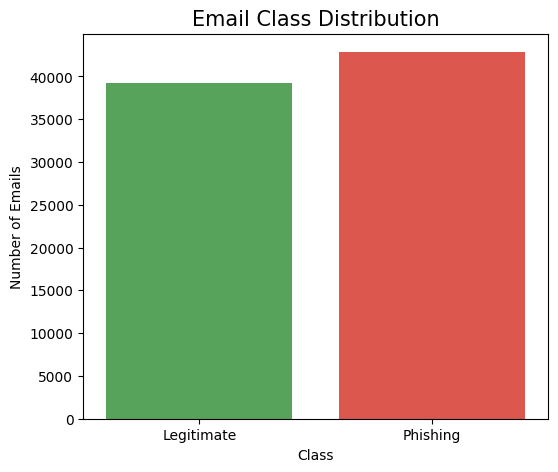

In [10]:
# Cell 8: Class distribution graph
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='label', palette=['#4CAF50', '#F44336'])
plt.xticks([0,1], ['Legitimate', 'Phishing'])
plt.title('Email Class Distribution', fontsize=15)
plt.xlabel('Class')
plt.ylabel('Number of Emails')
plt.show()

In [11]:
# Cell 9: Email length analysis
df['email_length'] = df['text_combined'].astype(str).str.len()
print(df['email_length'].describe(percentiles=[0.90, 0.95, 0.99]))

count    8.207800e+04
mean     1.290496e+03
std      1.553506e+04
min      1.000000e+00
50%      5.580000e+02
90%      2.764000e+03
95%      3.668000e+03
99%      9.033690e+03
max      4.279526e+06
Name: email_length, dtype: float64


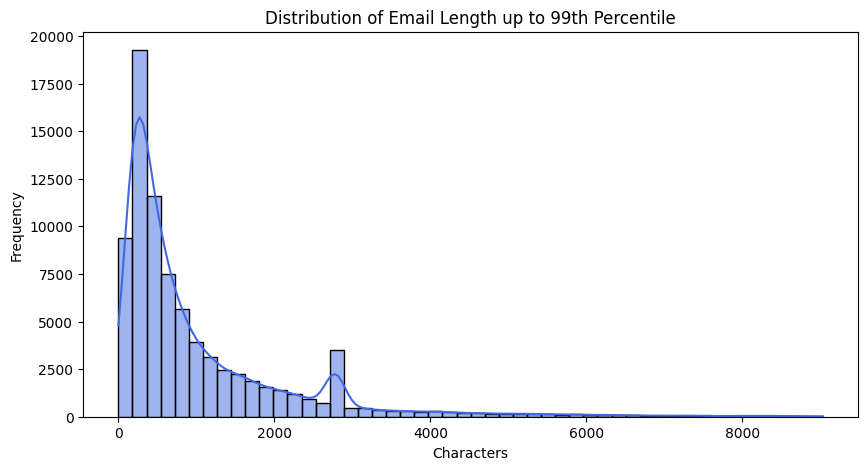

In [12]:
# Cell 10: Email length histogram with 99th percentile cap for clear visualization
cap = df['email_length'].quantile(0.99)
plt.figure(figsize=(10,5))
sns.histplot(df[df['email_length'] <= cap]['email_length'], bins=50, kde=True, color='royalblue')
plt.title('Distribution of Email Length up to 99th Percentile')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()

In [13]:
# Cell 11: Text cleaning function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)       # remove URLs
    text = re.sub(r'<.*?>', ' ', text)                 # remove HTML
    text = re.sub(r'\S+@\S+', ' ', text)              # remove emails
    text = re.sub(r'\d+', ' ', text)                  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

In [14]:
# Cell 12: Apply cleaning
# This may take a few minutes for 82K emails
df['clean_text'] = df['text_combined'].apply(clean_text)
df[['text_combined', 'clean_text', 'label']].head()

,text_combined,clean_text,label
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xl hplno xl,0
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols forwarded sabrae zajac hou ect...,0
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...,0
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xl hplno xl,0
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xl hplno xl,0


In [15]:
# Cell 13: Remove empty cleaned emails
df = df[df['clean_text'].str.strip() != '']
print('Final dataset shape after cleaning:', df.shape)

Final dataset shape after cleaning: (82075, 4)


In [16]:
# Cell 14: Train-test split before TF-IDF to avoid data leakage
X_text = df['clean_text']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training samples:', X_train_text.shape[0])
print('Testing samples :', X_test_text.shape[0])

Training samples: 65660
Testing samples : 16415


In [17]:
# Cell 15: TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)

X_train shape: (65660, 10000)
X_test shape : (16415, 10000)


In [18]:
# Cell 16: Define models
# Linear SVM is wrapped with calibration so that confidence score can be shown in Streamlit.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': CalibratedClassifierCV(LinearSVC(class_weight='balanced'), cv=3),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1, class_weight='balanced')
}

In [19]:
# Cell 17: Train and evaluate models
results = []
trained_models = {}

for name, model in models.items():
    print('='*60)
    print('Training:', name)
    model.fit(X_train, y_train)
    trained_models[name] = model
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    results.append([name, acc, pre, rec, f1])
    print('Accuracy :', round(acc, 4))
    print('Precision:', round(pre, 4))
    print('Recall   :', round(rec, 4))
    print('F1 Score :', round(f1, 4))

Training: Logistic Regression
Accuracy : 0.9811
Precision: 0.9809
Recall   : 0.9828
F1 Score : 0.9819
Training: Naive Bayes
Accuracy : 0.9567
Precision: 0.9835
Recall   : 0.9328
F1 Score : 0.9575
Training: Linear SVM
Accuracy : 0.9863
Precision: 0.9841
Recall   : 0.9897
F1 Score : 0.9869
Training: Random Forest
Accuracy : 0.9829
Precision: 0.984
Recall   : 0.9832
F1 Score : 0.9836


In [20]:
# Cell 18: Model comparison table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.986293,0.984101,0.989729,0.986907
1,Random Forest,0.982882,0.983997,0.983193,0.983595
2,Logistic Regression,0.981054,0.980897,0.982843,0.981869
3,Naive Bayes,0.956747,0.983510,0.932773,0.957470


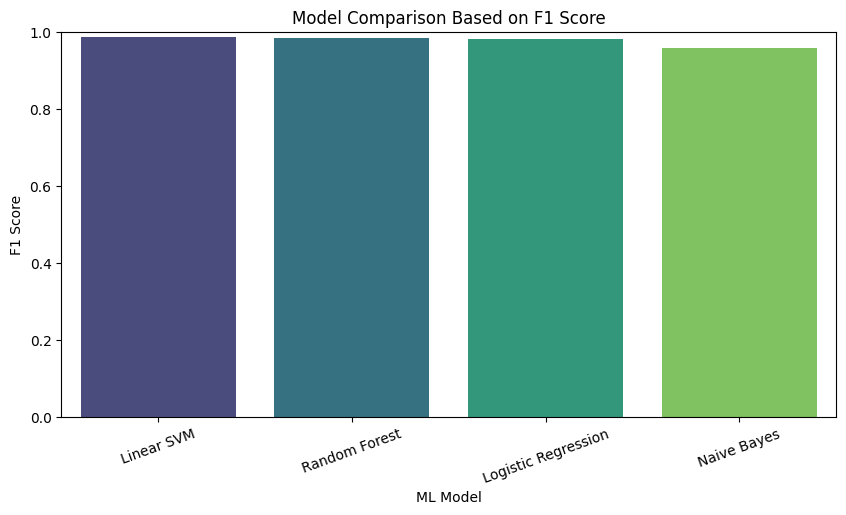

In [21]:
# Cell 19: Model comparison graph
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Model', y='F1 Score', palette='viridis')
plt.title('Model Comparison Based on F1 Score')
plt.xlabel('ML Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [22]:
# Cell 20: Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print('Best Model Selected:', best_model_name)
print(results_df.iloc[0])

Best Model Selected: Linear SVM
Model        Linear SVM
Accuracy       0.986293
Precision      0.984101
Recall         0.989729
F1 Score       0.986907
Name: 0, dtype: object


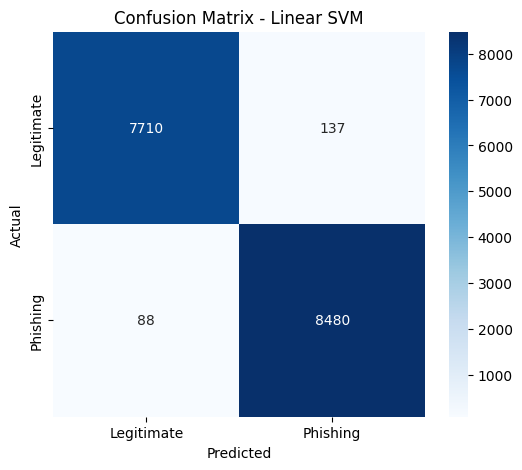

              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      7847
    Phishing       0.98      0.99      0.99      8568

    accuracy                           0.99     16415
   macro avg       0.99      0.99      0.99     16415
weighted avg       0.99      0.99      0.99     16415



In [23]:
# Cell 21: Confusion matrix for best model
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, best_pred, target_names=['Legitimate', 'Phishing']))

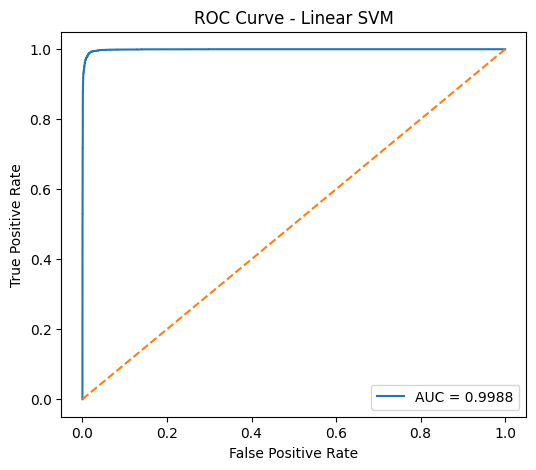

In [24]:
# Cell 22: ROC curve if probability is available
if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print('Selected model does not support probability output.')

In [25]:
# Cell 23: Save model, vectorizer, and results
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/phishing_model.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')
results_df.to_csv('model_results.csv', index=False)

df[['text_combined', 'clean_text', 'label']].to_csv('clean_phishing_dataset.csv', index=False)

print('Saved files:')
print('models/phishing_model.pkl')
print('models/vectorizer.pkl')
print('model_results.csv')
print('clean_phishing_dataset.csv')

Saved files:
models/phishing_model.pkl
models/vectorizer.pkl
model_results.csv
clean_phishing_dataset.csv


In [26]:
# Cell 24: Test prediction function

def predict_email(email_text):
    cleaned = clean_text(email_text)
    features = vectorizer.transform([cleaned])
    prediction = best_model.predict(features)[0]
    if hasattr(best_model, 'predict_proba'):
        confidence = max(best_model.predict_proba(features)[0])
    else:
        confidence = 0.85
    label = 'Phishing' if prediction == 1 else 'Legitimate'
    return label, confidence

sample_email = '''
Dear Customer,
Your PayPal account has been suspended due to suspicious activity.
Please verify your account immediately by clicking the link below.
http://paypal-security-login.xyz/verify
Failure to verify within 24 hours will permanently suspend your account.
'''

label, confidence = predict_email(sample_email)
print('Prediction:', label)
print('Confidence:', round(confidence*100, 2), '%')

Prediction: Phishing
Confidence: 100.0 %


In [27]:
# Cell 25: Download output files
from google.colab import files
files.download('models/phishing_model.pkl')
files.download('models/vectorizer.pkl')
files.download('model_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from google.colab import files
uploaded = files.upload()

Saving graph_analysis.py to graph_analysis.py
Saving intent_detection.py to intent_detection.py
Saving predict.py to predict.py
Saving risk_score.py to risk_score.py
Saving sender_analysis.py to sender_analysis.py
Saving url_analysis.py to url_analysis.py


In [35]:
!pip install gradio networkx matplotlib tldextract joblib

In [36]:
from predict import PhishingPredictor

predictor = PhishingPredictor(
    "phishing_model.pkl",
    "vectorizer.pkl"
)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [38]:
from google.colab import files
uploaded = files.upload()

Saving app.py to app.py


In [39]:
!python app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f1ad23f07a221589e3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.p